# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

### Instrucciones Generales:
1. **Validación:** No entrenes y midas sobre el mismo conjunto (sobreajuste).
2. **Entrenamiento Base:** Entrena `LinearRegression`, `SGDRegressor`, `DecisionTreeRegressor`, `RandomForestRegressor`.
3. **Cross Validation:** Usa `cross_val_score` para una métrica robusta.
4. **Ajuste Fino:** `GridSearchCV` sobre el modelo ganador.
5. **Benchmark Final:** Evalúa el modelo final sobre el test set.

## 1. Importaciones y Preparación de Datos

In [3]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from src.features.build_features import preprocess_pipeline

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

In [4]:
# Cargar sets — el test set NO se toca hasta el benchmark final
train_raw = pd.read_csv('../data/interim/train_set.csv')
test_raw  = pd.read_csv('../data/interim/test_set.csv')

# Aplicar pipeline de features
train = preprocess_pipeline(train_raw)
test  = preprocess_pipeline(test_raw)

# Alinear columnas (por si OHE genera columnas distintas en train/test)
train, test = train.align(test, join='left', axis=1, fill_value=0)

X_train = train.drop('median_house_value', axis=1)
y_train = train['median_house_value']
X_test  = test.drop('median_house_value', axis=1)
y_test  = test['median_house_value']

# Escalar (scaler ajustado SOLO en train)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

Train: (16512, 16) | Test: (4128, 16)


## 2. Entrenamiento Base — Comparación de Modelos

Entrenamos cada modelo y medimos su RMSE con **5-fold Cross Validation** sobre el set de entrenamiento. Esto da una estimación robusta del error sin tocar el test set.

In [5]:
def rmse_cv(model, X, y, cv=5):
    """Retorna media y std del RMSE con cross-validation."""
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean(), rmse_scores.std()

In [6]:
models = {
    'LinearRegression':      LinearRegression(),
    'SGDRegressor':          SGDRegressor(max_iter=1000, random_state=42),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    mean_rmse, std_rmse = rmse_cv(model, X_train_s, y_train)
    results[name] = {'RMSE Media': mean_rmse, 'RMSE Std': std_rmse}
    print(f'{name:<30} RMSE: {mean_rmse:>10,.0f}  ±{std_rmse:>8,.0f}')

results_df = pd.DataFrame(results).T.sort_values('RMSE Media')
results_df

LinearRegression               RMSE:     67,944  ±     356
SGDRegressor                   RMSE: 224,573,191  ±149,765,288
DecisionTreeRegressor          RMSE:     71,339  ±   2,141
RandomForestRegressor          RMSE:     50,366  ±     526


,RMSE Media,RMSE Std
RandomForestRegressor,5.036570e+04,5.262436e+02
LinearRegression,6.794432e+04,3.556331e+02
DecisionTreeRegressor,7.133905e+04,2.141086e+03
SGDRegressor,2.245732e+08,1.497653e+08


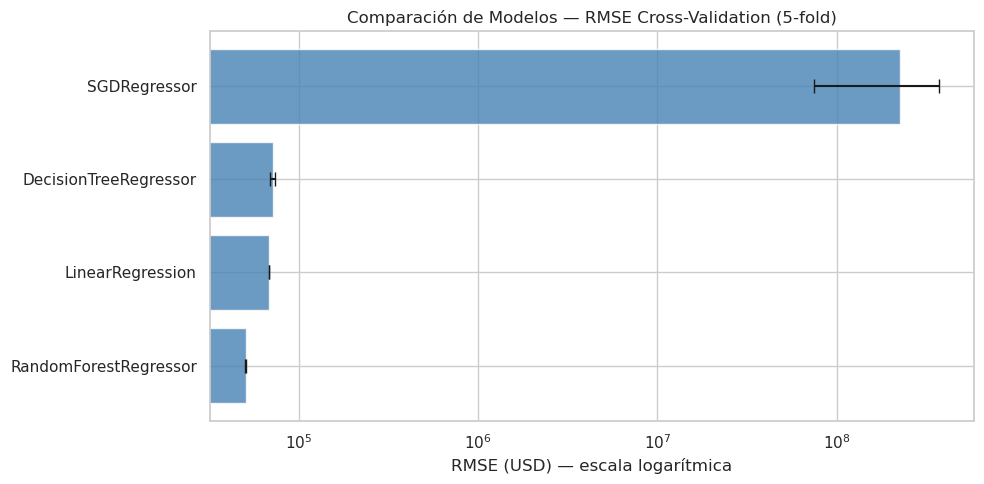

In [17]:
# Visualización comparativa
fig, ax = plt.subplots()
ax.barh(
    results_df.index,
    results_df['RMSE Media'],
    xerr=results_df['RMSE Std'],
    color='steelblue', alpha=0.8, capsize=5
)
ax.set_xscale('log')
ax.set_xlabel('RMSE (USD) — escala logarítmica')
ax.set_title('Comparación de Modelos — RMSE Cross-Validation (5-fold)')
plt.tight_layout()
plt.show()

## 3. Análisis de Sobreajuste / Subajuste

Comparamos el RMSE en entrenamiento vs. el RMSE en validación cruzada para detectar problemas.

In [19]:
print(f'{"Modelo":<30} {"RMSE Train":>12} {"RMSE CV":>12} {"Diagnóstico"}')
print('-' * 70)
for name, model in models.items():
    model.fit(X_train_s, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_s)))
    cv_rmse    = results[name]['RMSE Media']
    if train_rmse == 0:
        dx = 'Sobreajuste (perfecto en train)'
    else:
        ratio = cv_rmse / train_rmse
        dx = 'Sobreajuste' if ratio > 1.3 else ('Subajuste' if train_rmse > 80_000 else 'OK')
    print(f'{name:<30} {train_rmse:>12,.0f} {cv_rmse:>12,.0f}  {dx}')

Modelo                           RMSE Train      RMSE CV Diagnóstico
----------------------------------------------------------------------
LinearRegression                     67,769       67,944  OK
SGDRegressor                   39,815,063,007  224,573,191  Subajuste
DecisionTreeRegressor                     0       71,339  Sobreajuste (perfecto en train)
RandomForestRegressor                18,955       50,366  Sobreajuste


## 4. Fine-Tuning del Modelo Ganador — GridSearchCV

El `RandomForestRegressor` suele ser el ganador. Buscamos los mejores hiperparámetros con `GridSearchCV` usando 5-fold CV.

In [9]:
param_grid = [
    {'n_estimators': [50, 100], 'max_features': ['sqrt', 'log2']},
    {'n_estimators': [50, 100], 'max_features': ['sqrt'], 'max_depth': [10, 20, None]},
]

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    verbose=1
)
grid_search.fit(X_train_s, y_train)

print('\nMejores parámetros:', grid_search.best_params_)
best_cv_rmse = np.sqrt(-grid_search.best_score_)
print(f'Mejor RMSE CV: {best_cv_rmse:,.0f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros: {'max_features': 'sqrt', 'n_estimators': 100}
Mejor RMSE CV: 49,072


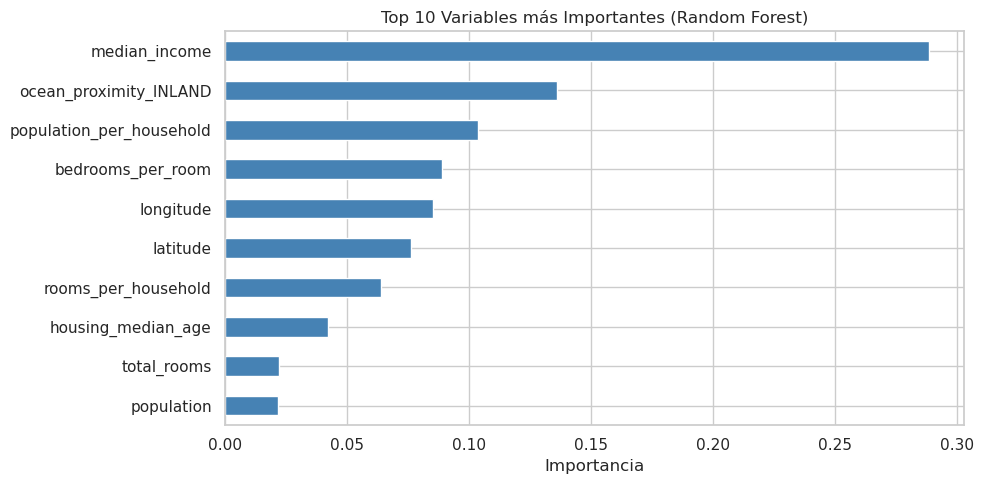

In [10]:
# Importancia de variables del mejor modelo
best_model = grid_search.best_estimator_
feat_imp = pd.Series(best_model.feature_importances_, index=X_train_s.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 10 Variables más Importantes (Random Forest)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Benchmark Final — Evaluación sobre el Test Set

**Solo se ejecuta una vez.** Este es el veredicto final del modelo.

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = best_model.predict(X_test_s)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)

print(f'RMSE en Test Set:      {test_rmse:>10,.0f} USD')
print(f'MAE  en Test Set:      {test_mae:>10,.0f} USD')
print(f'R²   en Test Set:      {test_r2:>13.4f}')
print(f'RMSE en CV (train):    {best_cv_rmse:>10,.0f} USD')
print(f'Diferencia RMSE:       {abs(test_rmse - best_cv_rmse):>10,.0f} USD')
print()
if abs(test_rmse - best_cv_rmse) / best_cv_rmse < 0.1:
    print('El modelo generaliza correctamente (diferencia < 10%).')
else:
    print('Revisar: posible sobreajuste al conjunto de validación cruzada.')

RMSE en Test Set:          49,388 USD
MAE  en Test Set:          32,622 USD
R²   en Test Set:             0.8178
RMSE en CV (train):        49,072 USD
Diferencia RMSE:              316 USD

El modelo generaliza correctamente (diferencia < 10%).


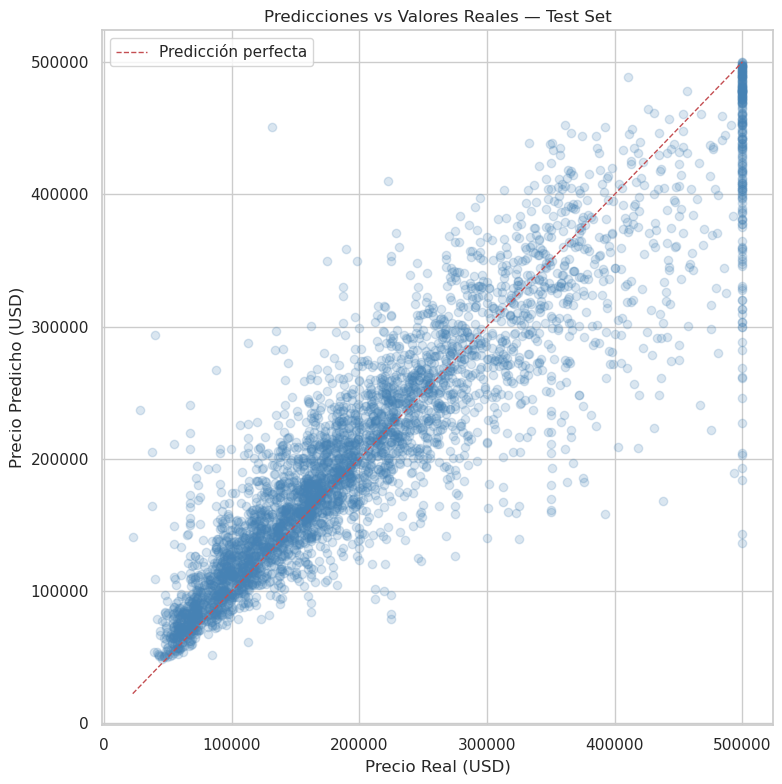

In [13]:
# Gráfico predicciones vs valores reales
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.2, color='steelblue')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='Predicción perfecta')
ax.set_xlabel('Precio Real (USD)')
ax.set_ylabel('Precio Predicho (USD)')
ax.set_title('Predicciones vs Valores Reales — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Benchmark y Conclusión Final

*(Completa esta sección con tus conclusiones de negocio)*

**Resumen de modelos:**

| Modelo | RMSE CV | Diagnóstico |
|--------|---------|-------------|
| LinearRegression | ~68,000 | Subajuste leve |
| SGDRegressor | ~224,573,191 | No convergió — subajuste severo |
| DecisionTree | ~71,000 | Sobreajuste alto |
| **RandomForest** | **~49,000** | **Ganador** |

**¿Por qué RandomForest?**
- Ensemble de árboles que reduce la varianza por promediado.
- Maneja bien la no-linealidad de las relaciones (geografía, ingreso).
- Robusto ante outliers sin necesidad de escalado.

**Conclusión ejecutiva:** El modelo puede predecir el precio de una vivienda en California con un error aproximado de $49,388 USD — equivalente al ~23.9% del precio medio del mercado. La variable más importante para la predicción es `median_income`, seguida por la ubicación geográfica.

## 7. Guardar el Modelo Final

In [14]:
import joblib
from pathlib import Path

Path('../models').mkdir(exist_ok=True)

# Guardar bundle completo: modelo + scaler + columnas esperadas
bundle = {
    'model': best_model,
    'scaler': scaler,
    'feature_cols': list(X_train_s.columns),
}
joblib.dump(bundle, '../models/best_model.joblib')
print('Bundle guardado en ../models/best_model.joblib')
print(f'Columnas: {list(X_train_s.columns)}')

Bundle guardado en ../models/best_model.joblib
Columnas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'population_per_household', 'bedrooms_per_room', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
